# Traffic Congestion Prediction Model

## Goal
The goal of this section is to train a machine learning model that can predict traffic speed based on engineered features.

This is an important step because:
- Traffic speed determines how congested a road is
- If we can predict speed, we can estimate travel time
- This allows us to choose the most efficient route

---

## What is a Model?

A model is a function that learns patterns from data and uses those patterns to make predictions.

In this project:
- Input (X): Features about the road, time, and traffic patterns
- Output (y): Traffic speed

The model learns:
"Given these conditions, what will the traffic speed be?"

---

## Datasets Used

We are primarily using the `congestion_ml` dataset for modeling.

### congestion_ml
This dataset contains:
- Engineered features (time, lag, rolling averages)
- Traffic-related metrics (volume, speed, travel time)
- Encoded categorical variables (borough, direction)

This is the dataset we use to TRAIN the model.

---

### routing_edges
This dataset represents the road network:
- Nodes (intersections)
- Edges (roads between nodes)
- Travel time and distance

This will be used later for routing.

---

### routing_nodes
This dataset contains:
- Node IDs
- Latitude and longitude

This helps map the road network spatially.

---

## Important
For this notebook, we only use `congestion_ml` for training the model.

In [ ]:
# imports

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [ ]:
## load dataset

df = pd.read_csv("congestion_ml.csv")
print(f"Rows and columns before cleaning {df.shape}")
df.head()


print(df.isnull().sum())


Rows and columns before cleaning (123334, 38)
SegmentID                     0
lat                           0
lon                           0
link_length_ft           123334
avg_median_tt_sec        123334
avg_median_speed_fps     123334
avg_n_samples            123334
avg_speed                     0
avg_travel_time               0
avg_vol_hist                  0
peak_vol_hist                 0
std_vol_hist                  0
peak_hour_hist                0
hour                          0
day_of_week                   0
is_weekend                    0
is_rush_hour                  0
hour_sin                      0
hour_cos                      0
month_sin                     0
month_cos                     0
dow_sin                       0
dow_cos                       0
vol_lag_1                     0
vol_lag_2                     0
vol_lag_3                     0
vol_rolling_avg_3             0
borough_Bronx                 0
borough_Brooklyn              0
borough_Manhattan         

## Data Cleaning

Before training any models, we need to ensure the dataset is clean.

Feature engineering (such as lag and rolling features) often creates missing values (NaN). These occur because some rows do not have enough historical data.

We remove these rows so the model only learns from complete and valid data.

In [ ]:
#Data before Clean
print("Shape before cleaning:",df.shape,"\n")
print("Missing values:")
print(df.isnull().sum())

Shape before cleaning: (123334, 38) 

Missing values:
SegmentID                     0
lat                           0
lon                           0
link_length_ft           123334
avg_median_tt_sec        123334
avg_median_speed_fps     123334
avg_n_samples            123334
avg_speed                     0
avg_travel_time               0
avg_vol_hist                  0
peak_vol_hist                 0
std_vol_hist                  0
peak_hour_hist                0
hour                          0
day_of_week                   0
is_weekend                    0
is_rush_hour                  0
hour_sin                      0
hour_cos                      0
month_sin                     0
month_cos                     0
dow_sin                       0
dow_cos                       0
vol_lag_1                     0
vol_lag_2                     0
vol_lag_3                     0
vol_rolling_avg_3             0
borough_Bronx                 0
borough_Brooklyn              0
borough_Manhattan 

In [ ]:
#Data Clean
df = df.dropna(axis=1, how="all")# drops columns where ALL values are NaN
print("Shape after cleaning:", df.shape)
print(df.isnull().sum())
df.head()


Shape after cleaning: (123334, 34)
SegmentID                0
lat                      0
lon                      0
avg_speed                0
avg_travel_time          0
avg_vol_hist             0
peak_vol_hist            0
std_vol_hist             0
peak_hour_hist           0
hour                     0
day_of_week              0
is_weekend               0
is_rush_hour             0
hour_sin                 0
hour_cos                 0
month_sin                0
month_cos                0
dow_sin                  0
dow_cos                  0
vol_lag_1                0
vol_lag_2                0
vol_lag_3                0
vol_rolling_avg_3        0
borough_Bronx            0
borough_Brooklyn         0
borough_Manhattan        0
borough_Queens           0
borough_Staten Island    0
Direction_EB             0
Direction_NB             0
Direction_SB             0
Direction_WB             0
Vol                      0
is_congested             0
dtype: int64


,SegmentID,lat,lon,avg_speed,avg_travel_time,avg_vol_hist,peak_vol_hist,std_vol_hist,peak_hour_hist,hour,...,borough_Brooklyn,borough_Manhattan,borough_Queens,borough_Staten Island,Direction_EB,Direction_NB,Direction_SB,Direction_WB,Vol,is_congested
0,-0.258833,-1.378228,-3.195527,1.689452,-0.567263,-0.604429,-0.443698,-0.518378,-2.255487,-1.652075,...,False,False,False,True,False,False,False,True,16.0,0
1,-0.258833,-1.378228,-3.195527,1.689452,-0.567263,-0.604429,-0.443698,-0.518378,-2.255487,-1.652075,...,False,False,False,True,False,False,False,True,19.0,0
2,-0.258833,-1.378228,-3.195527,1.689452,-0.567263,-0.604429,-0.443698,-0.518378,-2.255487,-1.652075,...,False,False,False,True,False,False,False,True,10.0,0
3,-0.258833,-1.378228,-3.195527,1.689452,-0.567263,-0.604429,-0.443698,-0.518378,-2.255487,-1.652075,...,False,False,False,True,False,False,False,True,12.0,0
4,-0.258833,-1.378228,-3.195527,1.689452,-0.567263,-0.604429,-0.443698,-0.518378,-2.255487,-1.507990,...,False,False,False,True,False,False,False,True,16.0,0


## Define Features (X) and Target (y)

We split the dataset into:

- Features (X): all columns used to make predictions  
- Target (y): the value we want to predict  

In this project, we predict **traffic speed**.

We remove the target column from X to prevent data leakage.

In [ ]:
# Feature Selection Mode (Choose ONE)

USE_LEAKAGE_SAFE_MODE = True  # change to False if you want simple version

if USE_LEAKAGE_SAFE_MODE:
    # clean ML version (recommended)
    drop_cols = [
        "avg_speed",
        "is_congested",
        "avg_travel_time",
    ]

    print("Using CLEAN MODE (recommended)")
else:
    # simple baseline version
    drop_cols = ["avg_speed", "is_congested"]

    print("Using SIMPLE MODE")

X = df.drop(columns=drop_cols) #dropping avg_speed and anything related to y.
y = df["avg_speed"] #created empty new target column y

print("X shape:", X.shape)
print("y shape:", y.shape)

#dropping segment ID so model learns from real signals
X = X.drop(columns=["SegmentID"])




Using CLEAN MODE (recommended)
X shape: (123334, 31)
y shape: (123334,)


## Train/Test Split

We divide the data into:

- Training set (80%) → used to train the model  
- Testing set (20%) → used to evaluate the model  

This allows us to test how well the model performs on unseen data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model 1: Linear Regression

Linear Regression is the simplest machine learning model.

It assumes that the relationship between features and the target is linear.

In this context, it tries to learn relationships like:
- higher traffic volume → lower speed  
- rush hour → slower traffic  

This model is useful as a baseline to compare more complex models against.

Sum Squared Error: 17383.39403372894
Mean Absolute Error: 0.7003585000553066
RMSE: 0.8394776157094905


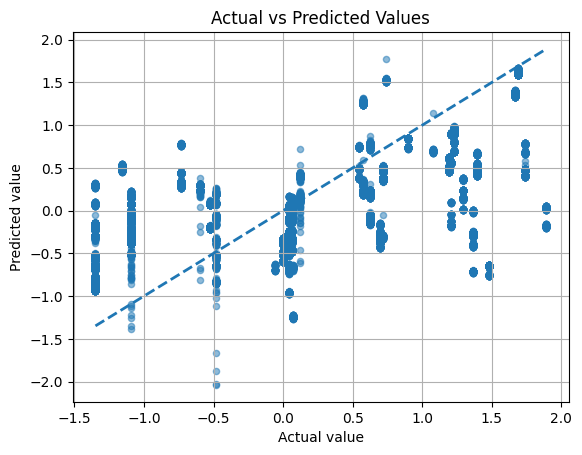

                  Feature  Coefficents:
0                     lat      0.263079
1                     lon      0.101650
2            avg_vol_hist     -0.178120
3           peak_vol_hist      0.226595
4            std_vol_hist      0.011427
5          peak_hour_hist     -0.087636
6                    hour      0.000612
7             day_of_week     -0.008817
8              is_weekend      0.020793
9            is_rush_hour      0.002897
10               hour_sin     -0.000954
11               hour_cos     -0.000748
12              month_sin     -0.022237
13              month_cos      0.134728
14                dow_sin      0.001929
15                dow_cos     -0.008892
16              vol_lag_1      0.190029
17              vol_lag_2      0.175293
18              vol_lag_3      0.167169
19      vol_rolling_avg_3     -0.506718
20          borough_Bronx     -0.458874
21       borough_Brooklyn     -0.244810
22      borough_Manhattan     -1.092193
23         borough_Queens      0.090283


'nThe linear regression model shows a positive relationship between actual and\npredicted values, indicating that it captures some underlying patterns in the data.\nHowever, the spread of points around the diagonal line suggests that the model\ndoes not fully capture the complexity of traffic behavior. The MAE and RMSE\nvalues indicate moderate prediction error, meaning the model performs reasonably\nbut could be improved with more complex models.'

In [ ]:
import matplotlib.pyplot as plt

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)


#--------Linear Regression Model-----------

#Sum squared error: total squared difference between actual and predicted values
sse = np.sum((y_test - lr_pred) ** 2)
print(f"Sum Squared Error: {sse}")

#Mean Absolute error: Avg magnitude of errors between predicted and actual values
mae = mean_absolute_error(y_test, lr_pred)
print(f"Mean Absolute Error: {mae}")

rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
print(f"RMSE: {rmse}")

#Plot of test
plt.figure()

plt.scatter(y_test, lr_pred, alpha=0.5, s=20) #(x,y) = (actual value, predicted value) | alpha to make points semi transparent, s to make dots smaller
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], linestyle = "--", linewidth = "2") #this draws line y=x
plt.xlabel("Actual value")
plt.ylabel("Predicted value")
plt.title("Actual vs Predicted Values")
plt.grid(True)
plt.show()
#points scattered around line means model is capturing some pattern, however,
#not perfectly.

# y = b0 + b1x1 + b2x2 + ... bnxn coefficents b and intercept b0 determine placement of "line".
coef_df = pd.DataFrame( {"Feature":X.columns, "Coefficents:":lr_model.coef_}) #Created dataframe of feature column to corresponding coefficent.
coef_df.sort_values(by = "Coefficents:", ascending = False) #Sorts features by importance(largest positive coefficent)
print(coef_df)

#Interpretation
"""nThe linear regression model shows a positive relationship between actual and
predicted values, indicating that it captures some underlying patterns in the data.
However, the spread of points around the diagonal line suggests that the model
does not fully capture the complexity of traffic behavior. The MAE and RMSE
values indicate moderate prediction error, meaning the model performs reasonably
but could be improved with more complex models."""


## Model 2: Decision Tree

A Decision Tree model splits the data into branches based on feature values.

It learns rules such as:
- if rush hour → predict lower speed  
- if weekend → predict higher speed  

This allows the model to capture non-linear patterns in traffic behavior.

DT Sum Squared Error: 6193.702725679387
DT Mean Absolute Error: 0.31145034146080713
DT Root Meam Squared Error: 0.5010914719912553


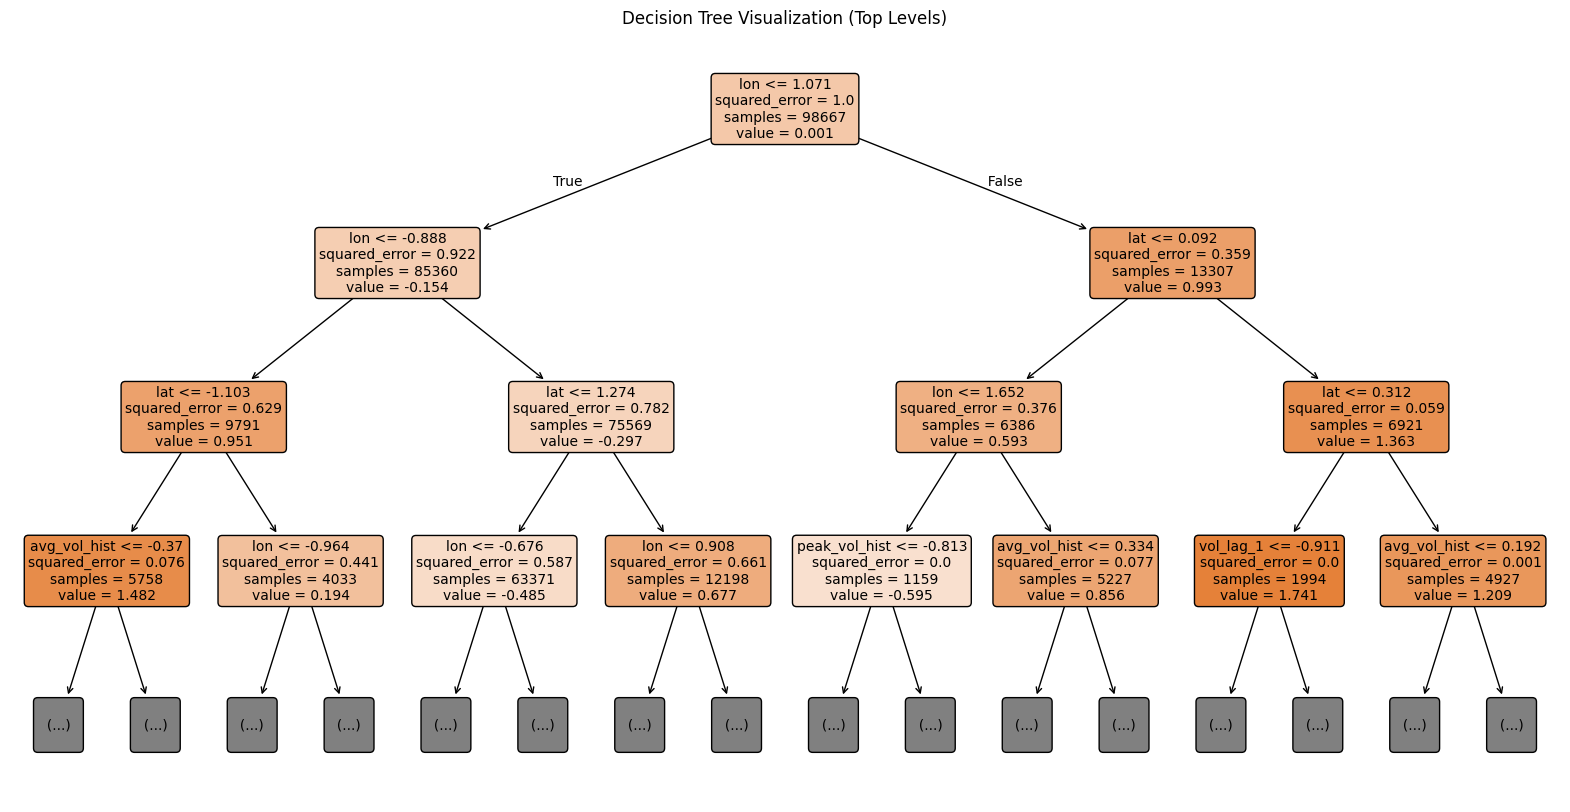

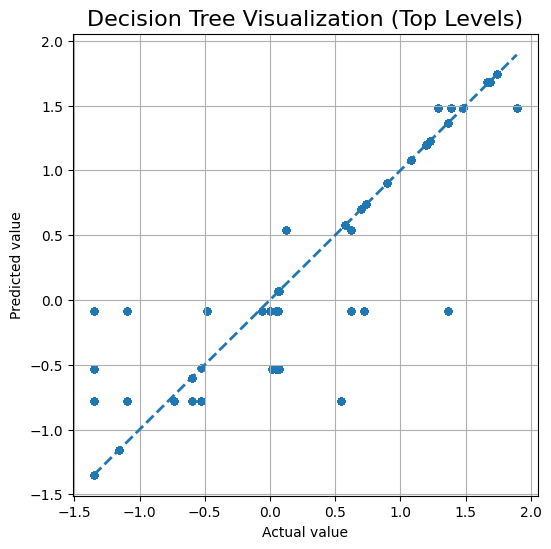

                  Feature    Importance
0                     lat  2.981576e-01
1                     lon  6.865012e-01
2            avg_vol_hist  8.133093e-03
3           peak_vol_hist  4.993377e-06
4            std_vol_hist  4.697924e-03
5          peak_hour_hist  3.827557e-04
6                    hour  0.000000e+00
7             day_of_week  0.000000e+00
8              is_weekend  0.000000e+00
9            is_rush_hour  0.000000e+00
10               hour_sin -1.540482e-17
11               hour_cos  0.000000e+00
12              month_sin  0.000000e+00
13              month_cos  0.000000e+00
14                dow_sin  0.000000e+00
15                dow_cos  0.000000e+00
16              vol_lag_1  5.359969e-15
17              vol_lag_2  0.000000e+00
18              vol_lag_3  0.000000e+00
19      vol_rolling_avg_3  2.087688e-17
20          borough_Bronx  0.000000e+00
21       borough_Brooklyn  0.000000e+00
22      borough_Manhattan  0.000000e+00
23         borough_Queens  0.000000e+00


'After I removed segment ID from features column\ndue to it have 46% importance in decision tree even though it was\njust a label, latitude and longitude now have the most importance.\nThis means location is determining decisions\n'

In [ ]:
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

#--------Data Tree Model-----------
# SSE DT
dt_sse = np.sum((y_test - dt_pred) ** 2)
print(f"DT Sum Squared Error: {dt_sse}")

# MAE DT
dt_mae = mean_absolute_error(y_test, dt_pred)
print(f"DT Mean Absolute Error: {dt_mae}")

# RMSE DT
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
print(f"DT Root Meam Squared Error: {dt_rmse}")

#Decision Tree Image
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)
plt.title("Decision Tree Visualization (Top Levels)")
plt.show()

#Scatter plot for Decision Tree
plt.figure(figsize=(6,6))

plt.scatter(y_test, dt_pred, alpha=0.5, s=20)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--',
    linewidth=2
)

plt.xlabel("Actual value")
plt.ylabel("Predicted value")
plt.title("Decision Tree: Actual vs Predicted")
plt.grid(True)

plt.title("Decision Tree Visualization (Top Levels)", fontsize=16)
plt.show()

#importance of features in decison tree's decision making
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
}) #dt_model.feature_importances_ is numbers showing
# how important each feature is

print(importance)

"""After I removed segment ID from features column
due to it have 46% importance in decision tree even though it was
just a label, latitude and longitude now have the most importance.
This suggests that traffic speed is strongly influenced by location,
meaning different areas have different traffic patterns.
"""


## Model Evaluation

We evaluate each model using:

- MAE (Mean Absolute Error): average difference between predicted and actual values  
- RMSE (Root Mean Squared Error): penalizes larger errors more  

Lower values indicate better performance.

In [ ]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

results = {}

results["Linear Regression"] = evaluate(y_test, lr_pred)
results["Decision Tree"] = evaluate(y_test, dt_pred)

for model, (mae, rmse) in results.items():
    print(f"{model} -> MAE: {mae:.4f}, RMSE: {rmse:.4f}")

Linear Regression -> MAE: 0.7004, RMSE: 0.8395
Decision Tree -> MAE: 0.3115, RMSE: 0.5011


## Model Comparison

We compare all models to determine which performs best.

The best model is the one with the lowest error.

This model will later be used in the routing algorithm to predict traffic speed and estimate travel time.

In [ ]:
pd.DataFrame(results, index=["MAE", "RMSE"]).T
#Decision Tree performed better with a lower error than linear regression.

,MAE,RMSE
Linear Regression,0.700359,0.839478
Decision Tree,0.311450,0.501091


## Final Interpretation

- Which model performed best?
- How much better was it compared to the others?
- Why might this model perform better?

In general:
- Linear Regression is simple but limited  
- Decision Trees capture more complex patterns  
- Random Forest combines multiple trees and often achieves the best performance  

The selected model will be used to predict traffic speeds, which will directly impact route optimization.

Final Interpretation:

The Decision Tree model performed better than Linear Regression.

- Linear Regression:
  MAE ≈ 0.7004, RMSE ≈ 0.8395

- Decision Tree:
  MAE ≈ 0.3115, RMSE ≈ 0.5011

The Decision Tree reduced error significantly (over 50% lower MAE), meaning its predictions are much closer to the actual traffic speeds.

This happens because traffic behavior is not purely linear. Factors such as location (latitude/longitude), traffic history, and time-related features create complex, non-linear relationships.

Linear Regression assumes a straight-line relationship, so it cannot capture these patterns well.

In contrast, the Decision Tree splits the data into regions based on feature values, allowing it to model different traffic behaviors in different conditions.

Feature importance shows that location (latitude and longitude) plays a major role in predictions, indicating that traffic speed varies significantly across different areas.

Therefore, the Decision Tree is a better model for predicting traffic speed in this dataset.

